In [1]:
# loading medical_cost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("hr_churn_dataset.csv")
df

,employee_id,age,gender,department,salary_level,years_at_company,performance_score,satisfaction_level,work_hours_per_week,promotion_last_5_years,churn
0,1,39,Male,Marketing,Low,1,4,0.02,52,0,1
1,2,41,Male,Marketing,Medium,5,1,0.38,57,0,0
2,3,48,Female,Marketing,High,13,3,0.69,39,1,0
3,4,28,Female,Marketing,Medium,8,3,0.09,31,1,0
4,5,58,Male,Marketing,High,3,3,0.78,37,0,0
...,...,...,...,...,...,...,...,...,...,...,...
995,996,33,Female,Operations,Low,7,1,0.49,53,1,1
996,997,37,Female,Operations,Medium,13,4,0.33,42,0,1
997,998,55,Male,Finance,Medium,7,4,0.17,55,0,1
998,999,53,Female,HR,Low,4,1,0.99,31,1,0


In [3]:
df.dtypes

,0
employee_id,int64
age,int64
gender,object
department,object
salary_level,object
years_at_company,int64
performance_score,int64
satisfaction_level,float64
work_hours_per_week,int64
promotion_last_5_years,int64


In [4]:
df.age.unique()

array([39, 41, 48, 28, 58, 38, 54, 24, 43, 46, 37, 60, 40, 42, 47, 34, 22,
       25, 45, 27, 52, 44, 56, 23, 50, 33, 51, 36, 29, 35, 57, 59, 55, 26,
       53, 31, 32, 30, 49])

In [5]:
df.isna().sum()

,0
employee_id,0
age,0
gender,0
department,0
salary_level,0
years_at_company,0
performance_score,0
satisfaction_level,0
work_hours_per_week,0
promotion_last_5_years,0


In [7]:
# label encoder sur sex
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [8]:
# frequency encoder sur department

In [9]:
#frequency encoding sur department
# Calcul des fréquences
freq_department = df['department'].value_counts(normalize=True)

# Remplacement des catégories par leur fréquence
df['department_freq'] = df['department'].map(freq_department)

# (Optionnel) supprimer la colonne originale
df.drop(columns='department', inplace=True)

df.head()

,employee_id,age,gender,salary_level,years_at_company,performance_score,satisfaction_level,work_hours_per_week,promotion_last_5_years,churn,department_freq
0,1,39,1,Low,1,4,0.02,52,0,1,0.164
1,2,41,1,Medium,5,1,0.38,57,0,0,0.164
2,3,48,0,High,13,3,0.69,39,1,0,0.164
3,4,28,0,Medium,8,3,0.09,31,1,0,0.164
4,5,58,1,High,3,3,0.78,37,0,0,0.164


In [10]:
# frequency encoder sur salary_level
# Calcul des fréquences
freq_salary_level = df['salary_level'].value_counts(normalize=True)

# Remplacement des catégories par leur fréquence
df['salary_level_freq'] = df['salary_level'].map(freq_salary_level)

# (Optionnel) supprimer la colonne originale
df.drop(columns='salary_level', inplace=True)

df.head()

,employee_id,age,gender,years_at_company,performance_score,satisfaction_level,work_hours_per_week,promotion_last_5_years,churn,department_freq,salary_level_freq
0,1,39,1,1,4,0.02,52,0,1,0.164,0.338
1,2,41,1,5,1,0.38,57,0,0,0.164,0.332
2,3,48,0,13,3,0.69,39,1,0,0.164,0.330
3,4,28,0,8,3,0.09,31,1,0,0.164,0.332
4,5,58,1,3,3,0.78,37,0,0,0.164,0.330


In [11]:
# séparer X et Y
X = df.drop('churn', axis=1)
y = df['churn']

In [12]:
# spliter X_train et x-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [13]:
# standardisation de X_train X_test, Y-train et Y-test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
X_train

array([[-1.61897442, -1.41854608,  0.99252792, ...,  1.0100505 ,
        -0.37945319, -0.96537639],
       [ 0.12989037,  0.77259708, -1.00752834, ..., -0.9900495 ,
         0.00512775,  1.40183008],
       [ 0.68289109, -1.5061918 , -1.00752834, ...,  1.0100505 ,
         1.79983878,  1.40183008],
       ...,
       [ 1.25317309, -0.45444309,  0.99252792, ..., -0.9900495 ,
         0.13332139, -0.96537639],
       [-0.21573509, -0.45444309, -1.00752834, ..., -0.9900495 ,
         1.79983878,  1.40183008],
       [-1.36666784,  0.42201417,  0.99252792, ..., -0.9900495 ,
         0.00512775, -0.37357477]])

In [15]:
# importer les librairies pour tensorflow
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [16]:
# Build model
model = Sequential()
model.add(Dense(10, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [19]:
ann = model.fit(X_train, y_train, epochs=500, validation_split=0.2, batch_size=16, verbose=1)
# verbose pour dire affiche les textes

Epoch 1/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7275 - loss: 0.5224 - val_accuracy: 0.4750 - val_loss: 0.8718
Epoch 2/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7334 - loss: 0.5058 - val_accuracy: 0.4750 - val_loss: 0.8697
Epoch 3/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7468 - loss: 0.5082 - val_accuracy: 0.4812 - val_loss: 0.8754
Epoch 4/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7645 - loss: 0.5052 - val_accuracy: 0.4688 - val_loss: 0.8810
Epoch 5/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7381 - loss: 0.5429 - val_accuracy: 0.4688 - val_loss: 0.8812
Epoch 6/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7502 - loss: 0.5117 - val_accuracy: 0.4938 - val_loss: 0.8849
Epoch 7/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7510 - loss: 0.5011 - val_accuracy: 0.4812 - val_loss: 0.8867
Epoch 8/500
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7297 - loss: 0.5275 - val_accuracy: 0.4875 - v

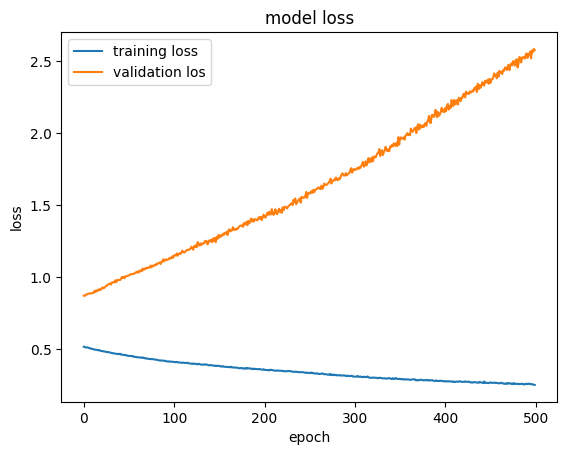

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

In [20]:
plt.plot(ann.history['loss'])
plt.plot(ann.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training loss', 'validation los'], loc='upper left')
plt.show()
plt

In [22]:
y_predict = model.predict(X_test)
y_predict_test = (y_predict > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


<Axes: >

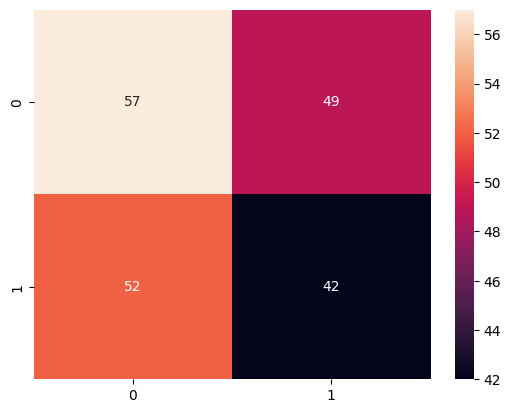

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
confusion_matrix(y_test, y_predict_test)
sns.heatmap(confusion_matrix(y_test, y_predict_test), annot=True)

In [24]:
# classification report
print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.52      0.54      0.53       106
           1       0.46      0.45      0.45        94

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.49      0.49      0.49       200



In [25]:
# sauvegarder le modèle
model.save('model_classification.h5')